<div style="background-color:#234c7d; border-radius:8px; padding:32px 40px 24px; margin-bottom:8px;">
  <h1 style="margin:0 0 6px; font-size:28px; font-weight:600; color:#C49A28; letter-spacing:-0.5px;">
    GA Image Approximation
  </h1>
  <p style="margin:0; font-size:13px; color:#a8b8d0; letter-spacing:0.5px;">
    Additional Insights Notebook
  </p>
</div>

<div style="border:1.5px solid #234c7d; border-radius:8px; padding:20px 40px; margin-bottom:8px; display:flex; gap:48px;">
  <div>
    <p style="margin:0 0 8px; font-size:11px; font-weight:600; color:#888; letter-spacing:1px; text-transform:uppercase;">Group 35 - Convergence</p>
    <p style="margin:0; font-size:14px; color:#2d2d2d; line-height:2;">
      Alexandra Rodrigues, 20250514 &nbsp;<br>
      Francisca Fernandes, 20250406 &nbsp;<br>
      Gonçalo Arrobas, 20250421 &nbsp;<br>
      Mariana Melo, 20250414  &nbsp;<br>
    </p>
  </div>
  <div>
    <p style="margin:0 0 8px; font-size:11px; font-weight:600; color:#888; letter-spacing:1px; text-transform:uppercase;">Course</p>
    <p style="margin:0; font-size:14px; color:#2d2d2d; line-height:2;">
      Computational Intelligence for Optimization<br>
      MSc in Data Science & Advanced Analytics<br>
      Nova Information Management School (NOVA IMS)<br>
      2025/2026
    </p>
  </div>
</div>

## **<span style="color:#234c7d">Table of Contents</span>**

- [1. Introduction](#1-introduction)

- [2. RMSE Heatmap Evolution](#2-environment-setup)
    - [2.1. Spark Session Setup](#21-spark-session-setup)
    - [2.2. Path Configuration](#22-path-configuration) 
- [3. Additional Target Images Experiments](#3-dataset-1)
    - [3.1. Exp. 1: Testing with another portrait painting - Monalisa](#21-spark-session-setup)
    - [3.2. Exp. 2: Testing with an image](#22-spark-session-setup)
    - [3.2. Exp. 2: Testing with a geometric painting](#23-spark-session-setup)

In [3]:
import os
import re
import sys
import csv
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from scipy import stats
from scipy.ndimage import gaussian_filter
from PIL import Image, ImageDraw

sys.path.insert(0, "../src")
from triangle import Triangle
from individual import Individual
from population import Population
from fitness import RMSEFitness
from ga import GeneticAlgorithm, GAConfig, EarlyStopping
from ga_utils import render, IMG_WIDTH, IMG_HEIGHT
from ga_operators.selection import TournamentSelection, RankSelection, RouletteSelection
from ga_operators.crossover import SinglePointCrossover, UniformCrossover, KPointCrossover, BlendCrossover, BlendCrossover,SegmentShuffleCrossover 
from ga_operators.mutation import GaussianMutation, CreepMutation, ResetMutation, SwapMutation, SigmaDecayScheduler

# 2. RMSE Heatmap Evolution

This section visualises **where** the GA is struggling at different points in the run, not just *how much* error remains overall.

For checkpoint image saved during training we compute a per-pixel squared error map against the original target, then aggregate it into a smooth RMSE heatmap (using a Gaussian blur so local structure is readable). We sample one frame every 500 generations from gen 500 onwards, plus the final best image, and lay them out in a grid so you can literally watch the algorithm solve the painting region by region.

**Interpretation:** bright yellow/red zones = high reconstruction error at that generation; dark blue = low error (well reconstructed). As generations increase the hot spots shrink and migrate to the hardest regions (fine detail, complex colour gradients).

target image: 300x400
found 94 checkpoint files, max gen = 9300
displaying 19 frames: [500, 1000, 1500, 2000, 2500] ... [8500, 9000, 9300]
pre-computing heatmaps for global normalisation ...
global max RMSE = 92.55


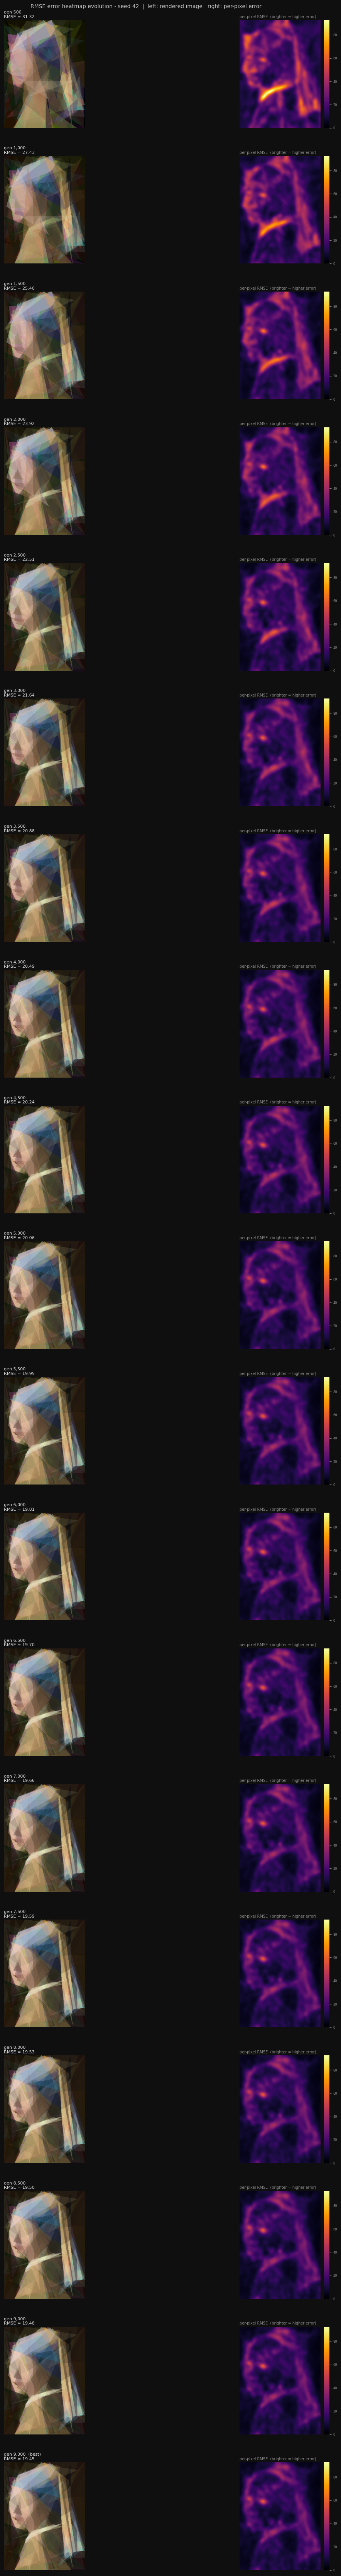

saved -> heatmap_evolution.png


In [4]:
# config
CHECKPOINT_DIR = "../runner_outputs/p12_final/seed_42/checkpoints"
TARGET_PATH    = "../data/Girl_Pearl_Earing.png"   
STEP           = 500   # sample one frame every N generations
BLUR_SIGMA     = 6     # gaussian blur applied to each heatmap (pixels)
CMAP           = "inferno"  # perceptually uniform, good for error maps

# load target
target_img = Image.open(TARGET_PATH).convert("RGB")
target_arr = np.array(target_img, dtype=np.float32)   # shape (H, W, 3)
H, W = target_arr.shape[:2]
print(f"target image: {W}x{H}")

# discover checkpoint files and parse generation numbers
# naming pattern: gen_<N>.png  or  gen_<N>_best.png etc.
# we accept any file whose name contains an integer after 'gen_' or 'generation_'
GEN_RE = re.compile(r"(?:gen(?:eration)?[_\-])(\d+)", re.IGNORECASE)

def parse_gen(fname):
    m = GEN_RE.search(fname)
    return int(m.group(1)) if m else None

all_files = [
    f for f in os.listdir(CHECKPOINT_DIR)
    if f.lower().endswith(".png") and parse_gen(f) is not None
]
all_files.sort(key=lambda f: parse_gen(f))

gen_to_file = {parse_gen(f): f for f in all_files}
all_gens    = sorted(gen_to_file.keys())
max_gen     = all_gens[-1]
print(f"found {len(all_gens)} checkpoint files, max gen = {max_gen}")

# build the list of generations to display:
# every STEP from STEP up to (max_gen - 1), then always include the last gen
# snap each target gen to the nearest available checkpoint
def nearest_available(target_g, available):
    """Return the available generation closest to target_g."""
    return min(available, key=lambda g: abs(g - target_g))

target_gens = list(range(STEP, max_gen, STEP)) + [max_gen]
selected_gens = []
seen = set()
for tg in target_gens:
    g = nearest_available(tg, all_gens)
    if g not in seen:
        selected_gens.append(g)
        seen.add(g)

print(f"displaying {len(selected_gens)} frames: {selected_gens[:5]} ... {selected_gens[-3:]}")

# compute per-pixel RMSE heatmap for a single checkpoint image
def rmse_heatmap(checkpoint_path):
    """Return a (H, W) heatmap of per-pixel RMSE vs target, blurred for readability."""
    gen_img  = Image.open(checkpoint_path).convert("RGB").resize((W, H))
    gen_arr  = np.array(gen_img, dtype=np.float32)
    sq_err   = np.mean((gen_arr - target_arr) ** 2, axis=2)  # per-pixel MSE over channels
    rmse_map = np.sqrt(sq_err)                                # -> RMSE in [0, 255]
    return gaussian_filter(rmse_map, sigma=BLUR_SIGMA)

# build the 2-column grid: left = rendered image, right = heatmap
# number of rows = number of selected frames
n_frames = len(selected_gens)
fig_h    = 3.5 * n_frames   # height scales with number of frames

fig = plt.figure(figsize=(10, fig_h), constrained_layout=True)
fig.patch.set_facecolor("#0f0f0f")

# global normalisation so all heatmaps share the same colour scale
print("pre-computing heatmaps for global normalisation ...")
heatmaps = []
for g in selected_gens:
    path = os.path.join(CHECKPOINT_DIR, gen_to_file[g])
    heatmaps.append(rmse_heatmap(path))

global_max = max(h.max() for h in heatmaps)
norm       = Normalize(vmin=0, vmax=global_max)
print(f"global max RMSE = {global_max:.2f}")

# outer spec: n_frames rows, 2 cols
outer = gridspec.GridSpec(n_frames, 2, figure=fig, wspace=0.04, hspace=0.12)

for row_idx, (g, hmap) in enumerate(zip(selected_gens, heatmaps)):
    path     = os.path.join(CHECKPOINT_DIR, gen_to_file[g])
    gen_img  = Image.open(path).convert("RGB").resize((W, H))

    is_last  = (g == max_gen)
    label    = f"gen {g:,}" + ("  (best)" if is_last else "")
    scalar_rmse = float(np.sqrt(np.mean((np.array(gen_img, dtype=np.float32) - target_arr) ** 2)))

    # -- left: rendered image --
    ax_img = fig.add_subplot(outer[row_idx, 0])
    ax_img.imshow(gen_img)
    ax_img.set_title(
        f"{label}\nRMSE = {scalar_rmse:.2f}",
        color="#e0e0e0", fontsize=8, pad=4, loc="left"
    )
    ax_img.axis("off")

    # right: heatmap 
    ax_heat = fig.add_subplot(outer[row_idx, 1])
    im = ax_heat.imshow(hmap, cmap=CMAP, norm=norm)
    ax_heat.set_title(
        "per-pixel RMSE  (brighter = higher error)",
        color="#888888", fontsize=7, pad=4, loc="left"
    )
    ax_heat.axis("off")

    # thin colorbar on the right of each heatmap row
    cbar = fig.colorbar(im, ax=ax_heat, fraction=0.035, pad=0.02)
    cbar.ax.tick_params(labelsize=6, colors="#888888")
    cbar.outline.set_edgecolor("none")

fig.suptitle(
    "RMSE error heatmap evolution - seed 42  |  left: rendered image   right: per-pixel error",
    color="#c0c0c0", fontsize=10, y=1.002
)

out_path = "heatmap_evolution.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"saved -> {out_path}")


---

---
## 3. Draw Order Significance

The chromosome encodes triangles as an **ordered list**: index 0 is rendered first (bottom layer) and index 99 last (top layer). This ordering is meaningful — a triangle at the top occludes everything beneath it, so the GA must jointly optimise *which* triangles to place *where* and in *what order*.

To test whether the GA actually learned a meaningful draw order (rather than just good colors and positions), we shuffle the triangle list of the best individual randomly N times, re-render each shuffle, and compare the resulting RMSE distribution against the original.

**Hypothesis:** if draw order carries information, the original should sit significantly below the shuffle distribution. We quantify this with a z-score and an empirical p-value (fraction of shuffles that beat the original).

In [ ]:
from scipy import stats as sp_stats

# ---------------------------------------------------------------------------
# config
# ---------------------------------------------------------------------------
TRIANGLES_PATH = "../runner_outputs/p12_final/seed_42/best_final_triangles.json"
N_SHUFFLES     = 200   # number of random permutations to sample
RNG_SEED       = 0

BG    = "#0f0f0f"
GOLD  = "#C49A28"
BLUE  = "#234c7d"
FG    = "#e0e0e0"
SUB   = "#888888"

# ---------------------------------------------------------------------------
# load triangles and build the best individual
# ---------------------------------------------------------------------------
with open(TRIANGLES_PATH) as f:
    tri_data = json.load(f)

fitness_fn   = RMSEFitness(target_arr.astype(np.uint8))
best_triangles = [Triangle.from_dict(t) for t in tri_data]

# original render and RMSE
original_render = render(tuple(best_triangles))
original_rmse   = float(np.sqrt(np.mean((original_render.astype(np.float32) - target_arr) ** 2)))
print(f"original RMSE: {original_rmse:.4f}")

# ---------------------------------------------------------------------------
# shuffle experiment
# ---------------------------------------------------------------------------
rng = np.random.default_rng(RNG_SEED)
shuffle_rmses = []

for i in range(N_SHUFFLES):
    perm      = rng.permutation(len(best_triangles))
    shuffled  = [best_triangles[j] for j in perm]
    rendered  = render(tuple(shuffled))
    rmse      = float(np.sqrt(np.mean((rendered.astype(np.float32) - target_arr) ** 2)))
    shuffle_rmses.append(rmse)
    if (i + 1) % 50 == 0:
        print(f"  shuffle {i+1}/{N_SHUFFLES}  current RMSE: {rmse:.4f}")

shuffle_rmses = np.array(shuffle_rmses)

# ---------------------------------------------------------------------------
# statistics
# ---------------------------------------------------------------------------
sh_mean  = shuffle_rmses.mean()
sh_std   = shuffle_rmses.std()
z_score  = (original_rmse - sh_mean) / sh_std
emp_p    = float(np.mean(shuffle_rmses <= original_rmse))  # fraction that beat original
pct      = float(sp_stats.percentileofscore(shuffle_rmses, original_rmse))

print(f"\n--- draw order significance ---")
print(f"shuffle mean RMSE : {sh_mean:.4f} +/- {sh_std:.4f}")
print(f"original RMSE     : {original_rmse:.4f}")
print(f"z-score           : {z_score:.3f}")
print(f"empirical p-value : {emp_p:.4f}  ({int(emp_p*N_SHUFFLES)}/{N_SHUFFLES} shuffles beat original)")
print(f"percentile        : {pct:.1f}th")

# ---------------------------------------------------------------------------
# plot
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4),
                         gridspec_kw=dict(width_ratios=[2, 1], wspace=0.35))
fig.patch.set_facecolor(BG)
for ax in axes:
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a2a2a")

# -- left: histogram of shuffle RMSEs --
ax = axes[0]
ax.hist(shuffle_rmses, bins=30, color=BLUE, alpha=0.85, edgecolor="none", label=f"shuffles (n={N_SHUFFLES})")
ax.axvline(original_rmse, color=GOLD, linewidth=2.0, linestyle="--", label=f"original  RMSE = {original_rmse:.2f}")
ax.axvline(sh_mean,       color="#cc4444", linewidth=1.2, linestyle=":",  label=f"shuffle mean = {sh_mean:.2f}")

# shaded 5th percentile region
p5 = float(np.percentile(shuffle_rmses, 5))
ax.axvspan(shuffle_rmses.min(), p5, alpha=0.12, color=GOLD, label="5th pct region")

ax.set_xlabel("RMSE", color=FG, fontsize=9)
ax.set_ylabel("count", color=FG, fontsize=9)
ax.set_title("Shuffle RMSE distribution vs original", color=FG, fontsize=10)
ax.tick_params(colors=SUB, labelsize=8)
ax.legend(fontsize=8, facecolor="#1a1a1a", edgecolor="#333", labelcolor=FG)

# -- right: summary stats table --
ax2 = axes[1]
ax2.axis("off")

rows_data = [
    ["metric",           "value"],
    ["original RMSE",    f"{original_rmse:.4f}"],
    ["shuffle mean",     f"{sh_mean:.4f}"],
    ["shuffle std",      f"{sh_std:.4f}"],
    ["z-score",          f"{z_score:.3f}"],
    ["empirical p",      f"{emp_p:.4f}"],
    ["percentile",       f"{pct:.1f}th"],
    ["shuffles beaten",  f"{N_SHUFFLES - int(emp_p*N_SHUFFLES)}/{N_SHUFFLES}"],
]

tbl = ax2.table(
    cellText=[[r[1]] for r in rows_data[1:]],
    rowLabels=[r[0] for r in rows_data[1:]],
    colLabels=[rows_data[0][1]],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.3, 1.6)

for (row_idx, col_idx), cell in tbl.get_celld().items():
    cell.set_facecolor("#161616" if row_idx % 2 == 0 else "#1e1e1e")
    cell.set_edgecolor("#2a2a2a")
    cell.set_text_props(color=GOLD if row_idx == 0 else FG)

ax2.set_title("Statistical summary", color=FG, fontsize=10, pad=12)

fig.suptitle(
    "Draw order significance test  |  does the GA learn meaningful triangle ordering?",
    color=FG, fontsize=10, y=1.02,
)

out_path = "draw_order_significance.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"saved -> {out_path}")
